In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import dalmatian
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('data/merged.deletions.csv')

In [3]:
df = df[df['contig']=='GFP_BAR_DSBR_2']

In [4]:
df[['cell_line','condition','timepoint','replicate']] = df['sample'].str.split('_',expand=True)

In [5]:
df_all = df.copy()

In [6]:
samples = [f'TK6_{c}_4h_BR0' for c in ['WT','LIG4','PolQ']]
df = df[df['sample'].isin(samples)]

In [7]:
df['sample'].value_counts()

sample
TK6_WT_4h_BR0      697
TK6_PolQ_4h_BR0    513
TK6_LIG4_4h_BR0    228
Name: count, dtype: int64

In [8]:
df = df.sort_values(['sample','deletion_length','start'],ascending=True)

In [33]:
def plot_deletions(df,min_x = 1,
                   max_x = 100,
                   dsb_pos = 43.5,
                   lw_thin=1,
                   lw_thick=2,
                   fontsize=6,
                   ax=None,
                   figsize=(5,8),
                   max_show=100):
    
    if ax is None:
        f,ax = plt.subplots(1,figsize=figsize)

    if max_show < df.shape[0]:
        df = df.sample(max_show,random_state=0)
        
    df = df.sort_values(['deletion_length','start'])
        
    i=0
    for ind,row in df.iterrows():

        color = 'green' if row['microhomology_length']>=3 else 'grey'
        
        ax.plot([min_x,row['start']],[i,i],linewidth=lw_thick,color=color)
        ax.plot([row['start'],row['end']+1],[i,i],linewidth=lw_thin,color='grey')
        ax.plot([row['end']+1,max_x],[i,i],linewidth=lw_thick,color=color)
    
        mh_sequence = row['deleted_sequence'][0:row['microhomology_length']]
    
        ax.text(row['start']+1,i,mh_sequence,fontsize=fontsize,va='center_baseline',ha='left',fontweight='bold')
        ax.text(row['end']+1,i,mh_sequence,fontsize=fontsize,va='center_baseline',ha='left',fontweight='bold')
        
        ax.axvline(dsb_pos,linestyle='--',linewidth=1,color='red')
        
        ax.set_yticks([])

        i +=1 

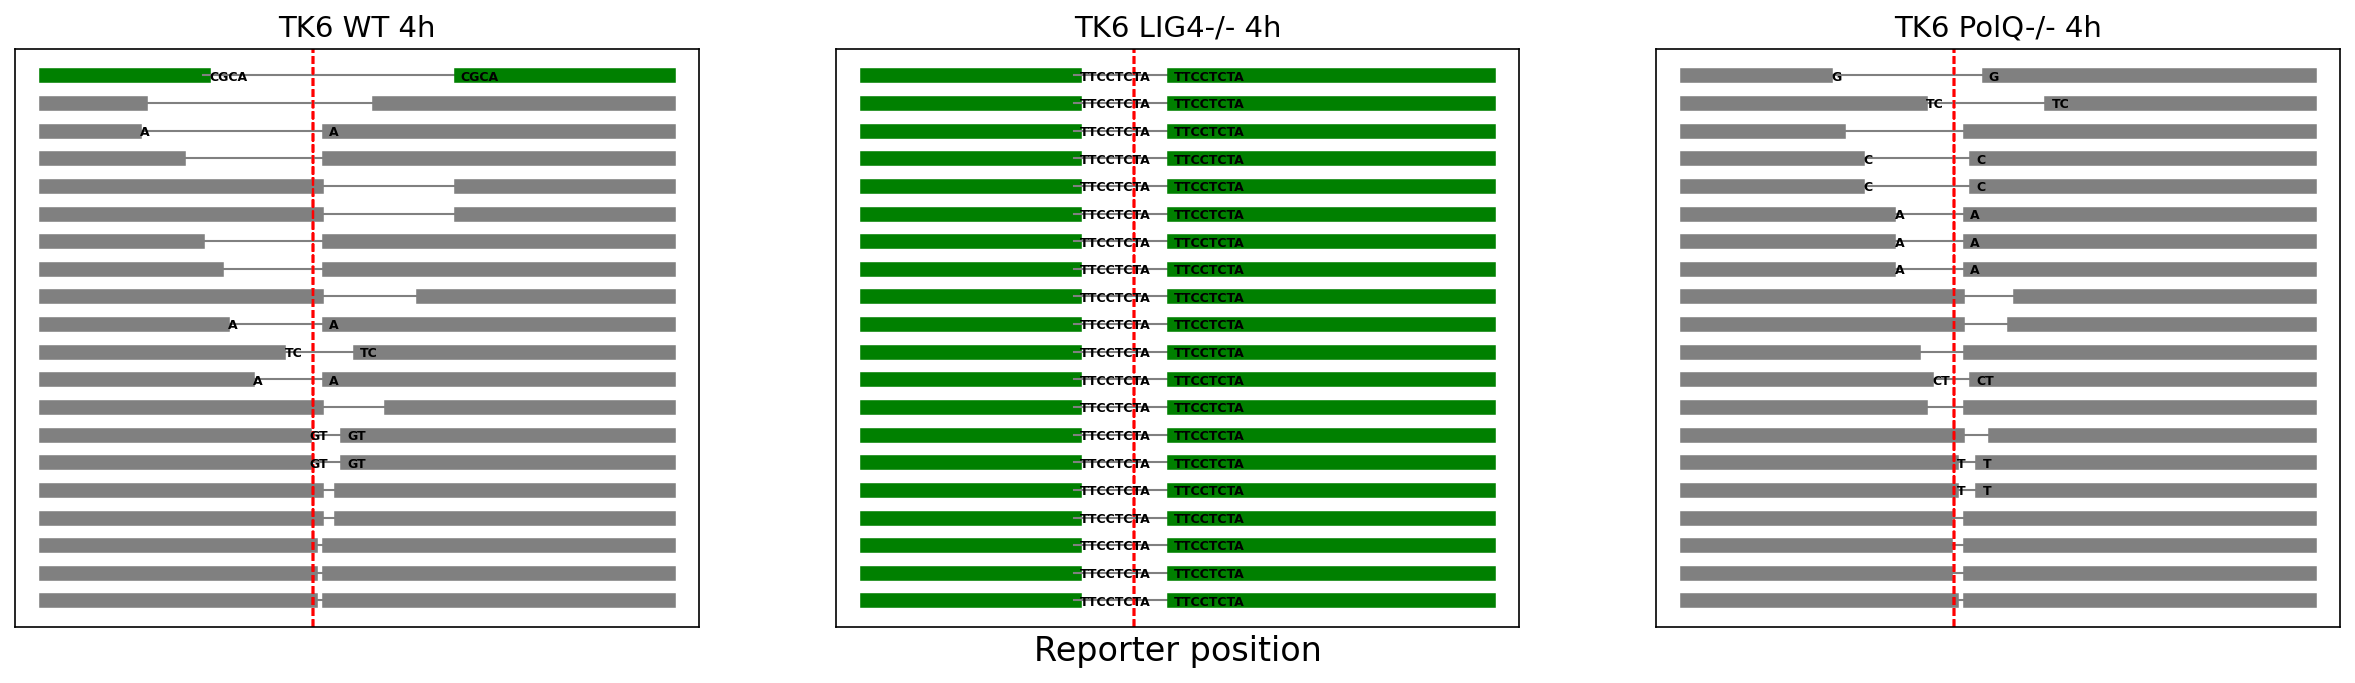

In [35]:
f,ax = plt.subplots(1,3,figsize=(20,5))

for i in range(0,len(samples)):
    plot_deletions(df[df['sample']==samples[i]],ax=ax[i],max_show=20,lw_thick=7)
    line,condition,timepoint,replicate = samples[i].split('_')

    if condition!='WT':
        condition = condition + '-/-'

    ax[i].set_title(f'{line} {condition} {timepoint}',fontsize=14)

    ax[i].set_xticks([])

ax[1].set_xlabel('Reporter position')
    
plt.savefig('figures/TK6_4h_deletions.pdf',bbox_inches="tight")

In [36]:
samples

['TK6_WT_4h_BR0', 'TK6_LIG4_4h_BR0', 'TK6_PolQ_4h_BR0']

In [44]:
!ls data

ko_experiment_qc_metrics.csv
ko_experiment_repair_measurements.csv
ko_experiment_reporter_counts.csv
merged.deletions.csv
merged.insertions.csv
merged.mismatch_dist.csv
merged.qc_metrics.csv
merged.repair_measurements.csv
merged.reporter_counts.csv
timecourse_experiment_qc_metrics.csv
timecourse_experiment_repair_measurements.csv
timecourse_experiment_reporter_counts.csv


In [211]:
C = pd.read_csv('data/merged.reporter_counts.csv')

In [212]:
C[['cell_line','condition','timepoint','replicate']] = C['sample'].str.split('_',expand=True)

In [213]:
C = C[(C['cell_line']=='TK6')&\
      (C['timepoint']=='4h')&\
      C['metric'].isin(['total','del','del_mh'])]

In [214]:
ctrl_counts = C[(C['reporter']=='GFP_BAR_010')&(C['metric']=='total')].set_index('sample')['count']

In [215]:
ctrl_counts.name='control_count'

In [216]:
C_dsb = C[C['reporter']=='GFP_BAR_DSBR_2'].join(ctrl_counts,on='sample')


In [217]:
C_dsb['counts_per_control'] = C_dsb['count'] / C_dsb['control_count']

In [220]:
C_dsb['label'] = C_dsb['metric'].map({'total' : 'Total DSB reporters',
                             'del' : 'DSB reproters with a deletion',
                             'del_mh' : 'DSB reporters with a deletion in 3+ microhomology'})

Text(0, 0.5, 'Reporters counts/control')

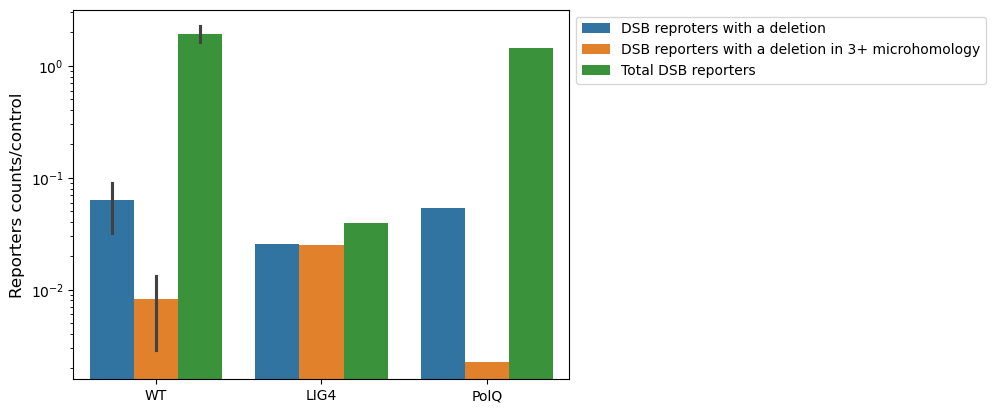

In [221]:
sns.barplot(x="condition",y="counts_per_control",hue="label",data=C_dsb)
plt.yscale('log')
plt.legend(bbox_to_anchor=(1,1))
plt.xlabel('')
plt.ylabel('Reporters counts/control',fontsize=12)

In [142]:
C_dsb

,Unnamed: 0,metric,reporter,count,sample,cell_line,condition,timepoint,replicate,control_count,total,frac,counts_per_control,label
312,312,del,GFP_BAR_DSBR_2,676,TK6_WT_4h_BR0,TK6,WT,4h,BR0,20948,33979,0.019895,0.032270,DSB reproters with a deletion
313,313,del_mh,GFP_BAR_DSBR_2,201,TK6_WT_4h_BR0,TK6,WT,4h,BR0,20948,33979,0.005915,0.009595,DSB reporters with a deletion in 2+ microhomology
317,317,total,GFP_BAR_DSBR_2,33979,TK6_WT_4h_BR0,TK6,WT,4h,BR0,20948,33979,1.000000,1.622064,Total DSB reporters
752,752,del,GFP_BAR_DSBR_2,243,TK6_LIG4_4h_BR0,TK6,LIG4,4h,BR0,9585,377,0.644562,0.025352,DSB reproters with a deletion
753,753,del_mh,GFP_BAR_DSBR_2,242,TK6_LIG4_4h_BR0,TK6,LIG4,4h,BR0,9585,377,0.641910,0.025248,DSB reporters with a deletion in 2+ microhomology
757,757,total,GFP_BAR_DSBR_2,377,TK6_LIG4_4h_BR0,TK6,LIG4,4h,BR0,9585,377,1.000000,0.039332,Total DSB reporters
1742,1742,del,GFP_BAR_DSBR_2,484,TK6_PolQ_4h_BR0,TK6,PolQ,4h,BR0,8951,12762,0.037925,0.054072,DSB reproters with a deletion
1743,1743,del_mh,GFP_BAR_DSBR_2,125,TK6_PolQ_4h_BR0,TK6,PolQ,4h,BR0,8951,12762,0.009795,0.013965,DSB reporters with a deletion in 2+ microhomology
1747,1747,total,GFP_BAR_DSBR_2,12762,TK6_PolQ_4h_BR0,TK6,PolQ,4h,BR0,8951,12762,1.000000,1.425762,Total DSB reporters
4712,4712,del,GFP_BAR_DSBR_2,648,TK6_WT_4h_BR2,TK6,WT,4h,BR2,9487,17449,0.037137,0.068304,DSB reproters with a deletion


In [126]:
C_dsb.groupby('sample').apply(lambda x : x['count'].values/x.loc[x['metric']=='total','count'].values)

sample
TK6_LIG4_4h_BR0       [0.6445623342175066, 0.6419098143236074, 1.0]
TK6_PolQ_4h_BR0    [0.03792509011126782, 0.009794703024604294, 1.0]
TK6_WT_4h_BR0      [0.01989464080755761, 0.005915418346625857, 1.0]
TK6_WT_4h_BR2      [0.03713679867041091, 0.013525130379964468, 1.0]
TK6_WT_4h_BR3      [0.04026335781210433, 0.015763484426437074, 1.0]
dtype: object

In [133]:
total = C_dsb[C_dsb['metric']=='total'].set_index('sample')['count']
total.name = 'total'

C_dsb = C_dsb.join(total,on='sample')
C_dsb['frac'] = C_dsb['count']/C_dsb['total']

Text(0, 0.5, 'Reporters counts/control')

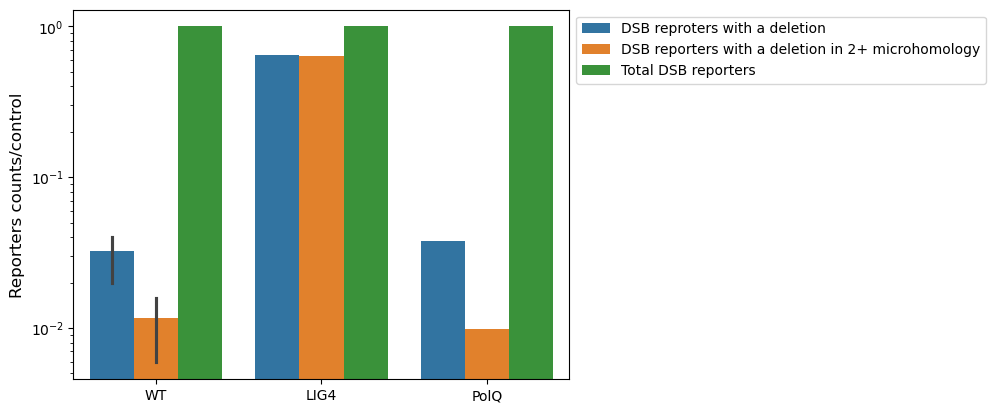

In [141]:
sns.barplot(x="condition",y="frac",hue="label",data=C_dsb)
plt.yscale('log')
plt.legend(bbox_to_anchor=(1,1))
plt.xlabel('')
plt.ylabel('Reporters counts/control',fontsize=12)

In [145]:
C_dsb[C_dsb['metric']=='del_mh']

,Unnamed: 0,metric,reporter,count,sample,cell_line,condition,timepoint,replicate,control_count,total,frac,counts_per_control,label
313,313,del_mh,GFP_BAR_DSBR_2,201,TK6_WT_4h_BR0,TK6,WT,4h,BR0,20948,33979,0.005915,0.009595,DSB reporters with a deletion in 2+ microhomology
753,753,del_mh,GFP_BAR_DSBR_2,242,TK6_LIG4_4h_BR0,TK6,LIG4,4h,BR0,9585,377,0.641910,0.025248,DSB reporters with a deletion in 2+ microhomology
1743,1743,del_mh,GFP_BAR_DSBR_2,125,TK6_PolQ_4h_BR0,TK6,PolQ,4h,BR0,8951,12762,0.009795,0.013965,DSB reporters with a deletion in 2+ microhomology
4713,4713,del_mh,GFP_BAR_DSBR_2,236,TK6_WT_4h_BR2,TK6,WT,4h,BR2,9487,17449,0.013525,0.024876,DSB reporters with a deletion in 2+ microhomology
5153,5153,del_mh,GFP_BAR_DSBR_2,498,TK6_WT_4h_BR3,TK6,WT,4h,BR3,14093,31592,0.015763,0.035337,DSB reporters with a deletion in 2+ microhomology


In [190]:
df = df_all[(df_all['cell_line']=='TK6')&\
      (df_all['timepoint']=='4h')]

<AxesSubplot:xlabel='sample', ylabel='microhomology_length'>

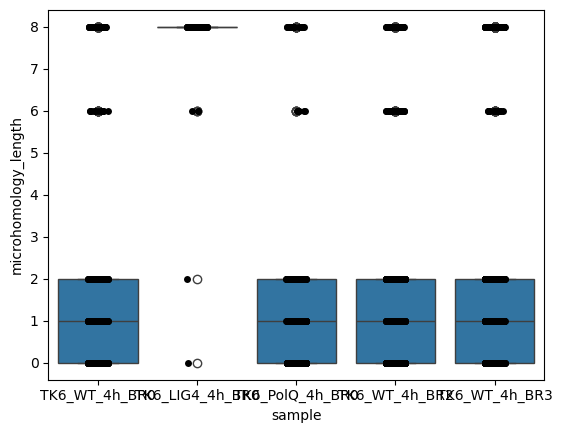

In [191]:
sns.boxplot(data=df,x="sample",y="microhomology_length")
sns.stripplot(data=df,x="sample",y="microhomology_length",color='k')


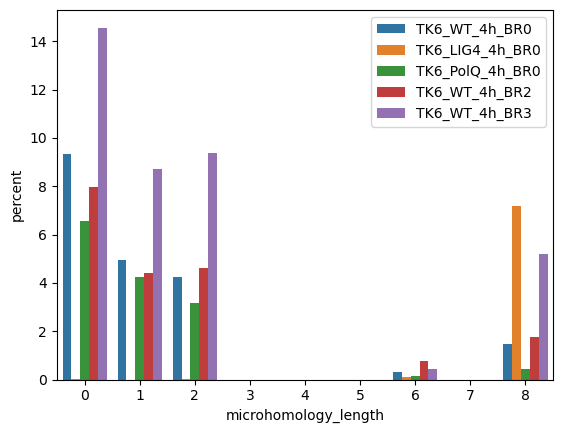

In [192]:
sns.countplot(x="microhomology_length",data=df,order = np.arange(0,9),hue="sample",stat="percent")
plt.legend(bbox_to_anchor=(1,1))

In [208]:
ct = df.groupby('sample')['microhomology_length'].value_counts().reset_index()
ct['percent'] = ct.groupby(['sample'])['count'].transform(lambda x : x/sum(x) * 100).values

In [209]:
ct = ct.join(df[['sample','condition']].drop_duplicates().set_index('sample'),on='sample',how='left')

<AxesSubplot:xlabel='microhomology_length', ylabel='percent'>

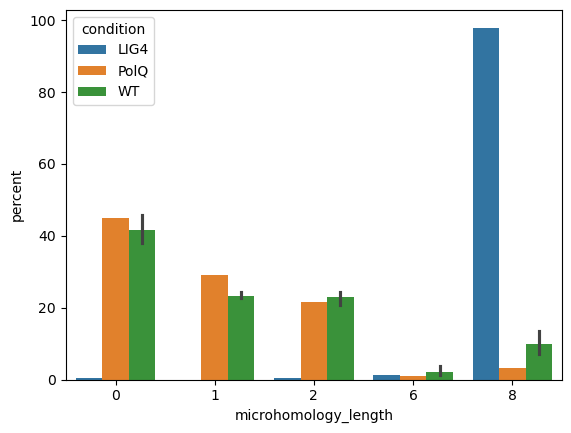

In [210]:
sns.barplot(x="microhomology_length",y="percent",hue="condition",data=ct)

In [205]:
ct

,sample,microhomology_length,count,percent,condition
0,TK6_LIG4_4h_BR0,8,238,97.942387,LIG4
0,TK6_LIG4_4h_BR0,8,238,97.942387,LIG4
0,TK6_LIG4_4h_BR0,8,238,97.942387,LIG4
0,TK6_LIG4_4h_BR0,8,238,97.942387,LIG4
0,TK6_LIG4_4h_BR0,8,238,97.942387,LIG4
...,...,...,...,...,...
23,TK6_WT_4h_BR3,6,15,1.179245,WT
23,TK6_WT_4h_BR3,6,15,1.179245,WT
23,TK6_WT_4h_BR3,6,15,1.179245,WT
23,TK6_WT_4h_BR3,6,15,1.179245,WT


In [206]:
ct[ct['microhomology_length']==8]

,sample,microhomology_length,count,percent,condition
0,TK6_LIG4_4h_BR0,8,238,97.942387,LIG4
0,TK6_LIG4_4h_BR0,8,238,97.942387,LIG4
0,TK6_LIG4_4h_BR0,8,238,97.942387,LIG4
0,TK6_LIG4_4h_BR0,8,238,97.942387,LIG4
0,TK6_LIG4_4h_BR0,8,238,97.942387,LIG4
...,...,...,...,...,...
22,TK6_WT_4h_BR3,8,172,13.522013,WT
22,TK6_WT_4h_BR3,8,172,13.522013,WT
22,TK6_WT_4h_BR3,8,172,13.522013,WT
22,TK6_WT_4h_BR3,8,172,13.522013,WT
